## Environment and Core Dependencies

This section initializes the Python environment by importing the necessary libraries for deep learning, data manipulation, and visualization.

- Core Deep Learning
    - **torch**, **torch.nn**, and **torch.optim** are used to design neural network architectures and define optimization strategies.

- Data Handling
    - **torchvision** provides access to the MNIST and FashionMNIST datasets, along with standard image transformations.

    - **DataLoader** is employed to handle data batching and shuffling efficiently.

- Utilities
    - **copy** is used for model parameter duplication and aggregation.
    
    - **csv** supports structured logging and storage of experimental results.

In [2]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset, ConcatDataset
from torchvision import datasets, transforms
from torchvision.models import resnet18
import csv
import random
import os
import requests
import zipfile
import io

In [3]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 92.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 49.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import matplotlib.pyplot as plt

## Data Management and Distribution Analysis

This section contains the core logic for preparing the MNIST dataset and simulating a Federated Learning environment through data partitioning.

### `load_data_mnist`
Configures the MNIST training and testing datasets. A normalization transform is applied using the standard MNIST mean (**0.1307**) and standard deviation (**0.3081**) to ensure the data is properly centered and scaled for neural network training.

### `get_iid_partitions`
Implements the data distribution strategy across federated clients. This function simulates an Independent and Identically Distributed (IID) setting by randomly shuffling dataset indices and assigning an equal number of samples to each client, ensuring that each local node receives a representative subset of the global data distribution.

### `analyze_client_distribution`
Acts as a diagnostic and validation utility for the data partitioning process. It computes the frequency of each digit (class) per client and exports the results to a CSV file. Additionally, it generates a stacked bar chart illustrating label distributions across a selected subset of clients, enabling visual verification of the IID or Non-IID characteristics of the data.


In [ ]:
def load_data_mnist():
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)) 
    ])
    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
    return train_dataset, test_dataset

def get_iid_partitions(dataset, num_clients):
    """
    IID Partition
    """
    num_items = int(len(dataset) / num_clients)
    dict_users, all_idxs = {}, [i for i in range(len(dataset))]
    for i in range(num_clients):
        dict_users[i] = set(np.random.choice(all_idxs, num_items, replace=False))
        all_idxs = list(set(all_idxs) - dict_users[i])
    return dict_users

def analyze_client_distribution(dataset, user_groups, subset_clients=25):
    all_clients = sorted(list(user_groups.keys()))
    
    csv_filename = "client_data_distribution.csv"
    targets = np.array(dataset.targets)
    num_classes = 10
    
    print(f"Saving distribution to {csv_filename}...")
    with open(csv_filename, mode='w', newline='') as file:
        writer = csv.writer(file)
        header = ['Client_ID'] + [f'Class_{i}' for i in range(num_classes)]
        writer.writerow(header)
        
        for client_id in all_clients:
            indices = list(user_groups[client_id])
            client_targets = targets[indices]
            counts = np.bincount(client_targets, minlength=num_classes)
            row = [client_id] + list(counts)
            writer.writerow(row)
            
    print(f"Plotting distribution for {subset_clients} random clients...")
    selected_clients = np.random.choice(all_clients, min(len(all_clients), subset_clients), replace=False)
    selected_clients.sort()
    
    client_data = []
    for client_id in selected_clients:
        indices = list(user_groups[client_id])
        client_targets = targets[indices]
        counts = np.bincount(client_targets, minlength=num_classes)
        client_data.append(counts)
    
    client_data = np.array(client_data)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bottom = np.zeros(len(selected_clients))
    colors = plt.cm.get_cmap('tab10', num_classes)
    
    for class_id in range(num_classes):
        ax.bar(range(len(selected_clients)), client_data[:, class_id], 
               bottom=bottom, label=f'Class {class_id}', color=colors(class_id))
        bottom += client_data[:, class_id]
        
    ax.set_xticks(range(len(selected_clients)))
    ax.set_xticklabels([f'C{i}' for i in selected_clients], rotation=45)
    ax.set_xlabel('Client ID')
    ax.set_ylabel('Number of Samples')
    ax.set_title('Label Distribution per Client')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('client_distribution.png')
    plt.show()

In [ ]:
def get_non_iid_partitions(dataset, num_clients,dirichlet_alpha=0.9, seed=1001):
    """
    Non-IID Partition
    """
    np.random.seed(seed)
    
    if isinstance(dataset.targets, torch.Tensor):
        targets = dataset.targets.numpy()
    else:
        targets = np.array(dataset.targets)
    
    num_classes = len(np.unique(targets))
    min_size = 0
    client_dict = {}

    while min_size < 10:
        client_dict = {i: [] for i in range(num_clients)}
        for k in range(num_classes):
            idx_k = np.where(targets == k)[0]
            np.random.shuffle(idx_k)
            proportions = np.random.dirichlet(np.repeat(dirichlet_alpha, num_clients))
            proportions = np.array([p * (len(idx_j) < len(targets) / num_clients) for p, idx_j in zip(proportions, client_dict.values())])
            proportions = proportions / proportions.sum()
            proportions = (np.cumsum(proportions) * len(idx_k)).astype(int)[:-1]
            client_splits = np.split(idx_k, proportions)
            for i, split in enumerate(client_splits):
                client_dict[i].extend(split.tolist())
        min_size = min([len(c) for c in client_dict.values()])
    return client_dict

## Out-of-Distribution (OOD) Data Acquisition

This section defines the retrieval of data intended to serve as Public Out-of-Distribution (POOD) examples. In the Federated Clean-Label Backdoor (FCLB) framework, the attacker leverages POOD samples—data that are semantically related to the target task but absent from the true training distribution—to train a surrogate model. This surrogate is then used to extract robust features for the target label and to optimize the backdoor trigger.

### `get_pood_dataset_fashion_mnist`
This function downloads the **FashionMNIST** dataset and selects a subset of a predefined size to act as the POOD source. It applies the same normalization parameters as those used for MNIST (mean **0.1307**, standard deviation **0.3081**) to ensure that the surrogate model processes out-of-distribution samples within a consistent feature space relative to the target dataset.


In [6]:
def get_pood_dataset_fashion_mnist(size=1000):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)) 
    ])
    pood_data = datasets.FashionMNIST('./data', train=True, download=True, transform=transform)
    indices = np.random.choice(len(pood_data), size, replace=False)
    return Subset(pood_data, indices)

## Model Architectures

This section defines the neural network structures employed by both the global server and the local clients. The analysis emphasizes that the Federated Clean-Label Backdoor (FCLB) attack remains effective even when the surrogate model architecture used for trigger generation differs from the target architecture deployed during federated training.

### `get_resnet18_mnist`
Builds a ResNet-18 architecture adapted for the MNIST dataset. The initial convolutional layer is modified to accept a single-channel grayscale input rather than the standard three-channel RGB input. The final fully connected layer is configured to produce outputs for ten classes.

### `SimpleCNN`
Defines a custom convolutional neural network composed of two convolutional layers, each followed by batch normalization and max-pooling. The network concludes with two fully connected layers and serves as the reference model for the federated training rounds.


In [ ]:
def get_resnet18_mnist(num_classes=10):
    """
    Modified ResNet18 for MNIST:
    - Input channels: 1 (instead of 3)
    - Num classes: 10
    """
    model = resnet18(num_classes=num_classes)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 5) 
        self.bn1 = nn.BatchNorm2d(16)
        
        self.conv2 = nn.Conv2d(16, 32, 5)
        self.bn2 = nn.BatchNorm2d(32)
        
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(32 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 10) 

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        
        x = x.view(x.size(0), -1) 
        
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def get_simple_cnn():
    return SimpleCNN()

## Label Shifting for Class Separation

This section implements a dataset wrapper designed to enforce strict class separation between Public Out-of-Distribution (POOD) data and the original training data.

### `ShiftedDataset`
A custom `Dataset` class that applies a fixed offset to the labels of an underlying dataset. This mechanism ensures that POOD samples (e.g., FashionMNIST) are mapped to label indices disjoint from those of the target dataset (e.g., MNIST). Such separation is essential for training the surrogate model to learn class-discriminative features required during the backdoor trigger optimization phase.


In [10]:
class ShiftedDataset(Dataset):
    def __init__(self, dataset, shift):
        self.dataset = dataset
        self.shift = shift
    def __getitem__(self, index):
        img, label = self.dataset[index]
        return img, label + self.shift
    def __len__(self):
        return len(self.dataset)

## Trigger Generation Logic (Algorithm 1)

This section implements the Federated Clean-Label Backdoor (FCLB) trigger generation procedure, which constitutes the foundational step of the clean-label attack.

### `TriggerGenerator`
This class encapsulates a three-phase optimization pipeline designed to synthesize a clean-label backdoor trigger:

- **Phase 1 — Surrogate Training**  
  The surrogate model is trained on a mixed dataset composed of Public Out-of-Distribution (POOD) samples and genuine target-class examples. This phase enables the model to learn a shared and expressive feature space.

- **Phase 2 — Fine-tuning**  
  The surrogate model is subsequently fine-tuned exclusively on the target class. This step sharpens the internal representation of the target label, reinforcing class-specific features.

- **Phase 3 — Trigger Optimization**  
  A trigger is generated by solving an optimization problem that maximizes the likelihood that a POOD sample, once poisoned, is classified as the target class. The optimized trigger effectively captures the most representative and discriminative features of the target label.


In [11]:
class TriggerGenerator:
    def __init__(self, surrogate_model, pood_dataset, target_samples, device, target_class_idx, epsilon):
        self.model = surrogate_model.to(device)
        self.pood_loader = DataLoader(pood_dataset, batch_size=64, shuffle=True)
        self.target_loader = DataLoader(target_samples, batch_size=32, shuffle=True)
        self.device = device
        self.target_class_idx = target_class_idx
        self.epsilon = epsilon
        self.criterion = nn.CrossEntropyLoss()

    def generate(self, t1=20, t2=5, t3=2000):
        # Phase 1: Train Surrogate on POOD + Target Samples
        optimizer = optim.SGD(self.model.parameters(), lr=0.01, momentum=0.9)
        combined_data = ConcatDataset([self.pood_loader.dataset, self.target_loader.dataset])
        loader = DataLoader(combined_data, batch_size=64, shuffle=True)
        
        self.model.train()
        for _ in range(t1):
            for inputs, labels in loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                optimizer.zero_grad()
                
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                
                optimizer.step()

        # Phase 2: Fine-tune strictly on the Target Class 
        for _ in range(t2):
            for inputs, labels in self.target_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                optimizer.zero_grad()
                
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                loss.backward()
                
                optimizer.step()

        # Phase 3: Optimize Trigger (Eq. 6)
        self.model.eval()
        delta = torch.zeros((1, 1, 28, 28), device=self.device, requires_grad=True)
        opt_delta = optim.Adam([delta], lr=0.01)

        for _ in range(t3):
            for inputs, _ in self.pood_loader:
                inputs = inputs.to(self.device)
                target_labels = torch.full((inputs.size(0),), self.target_class_idx, dtype=torch.long, device=self.device)

                poisoned_input = torch.clamp(inputs + delta, 0, 1)
                outputs = self.model(poisoned_input)
                loss = self.criterion(outputs, target_labels)
                
                opt_delta.zero_grad()
                loss.backward()
                opt_delta.step()
                
                with torch.no_grad():
                    delta.clamp_(-self.epsilon, self.epsilon)

        return delta.detach()

## Malicious Client Implementation (FCLB Methodology)

This section specifies the behavior of a compromised participant within the federated learning network. In contrast to conventional dirty-label attacks that rely on label manipulation, this design adheres strictly to the Federated Clean-Label Backdoor (FCLB) paradigm.

### `MaliciousClient`
This class governs the local training routine of an adversarial client and implements two key components of the FCLB methodology:

- **Deviation Reduction (Step 2)**  
  To evade anomaly and outlier detection mechanisms, the client integrates a Euclidean distance constraint into its loss function (as formalized in Equation 7). This regularization term limits the divergence between the malicious local model parameters and the current global model.

- **Subtle Unlearning (Step 3)**  
  To avoid the “lazy attack” phenomenon—where the backdoor effect diminishes as global training converges—the client periodically performs an unlearning step. This is achieved via gradient ascent on a small subset of target-class samples, ensuring the persistence and effectiveness of the backdoor across training rounds.


In [ ]:
class MaliciousClient:
    def __init__(self, client_id, dataset, idxs, device, model_fn, args, trigger, clean_target_samples):
        self.client_id = client_id
        self.device = device
        self.model_fn = model_fn
        self.args = args
        self.trigger = trigger.to(device).squeeze(0) if trigger.dim() == 4 else trigger.to(device)

        # 1. Data Preparation
        all_targets = np.array(dataset.targets)
        self.benign_indices = [idx for idx in idxs if all_targets[idx] != args.target_class]
        self.target_indices = [idx for idx in idxs if all_targets[idx] == args.target_class]
        
        self.benign_data = Subset(dataset, self.benign_indices)
        self.target_data = Subset(dataset, self.target_indices)

        # 2. Poisoned Dataset (Algorithm 2)
        self.train_loader = DataLoader(
            ConcatDataset([self.benign_data, self.target_data]), 
            batch_size=32, 
            shuffle=True
        )
        
        # 3. Loader for Subtly Unlearn (Step 3)
        unlearn_size = min(len(clean_target_samples), 50)
        self.unlearn_loader = DataLoader(
            Subset(clean_target_samples, range(unlearn_size)), 
            batch_size=32, 
            shuffle=True
        )

    def _perform_unlearning(self, model):
        """
        Maximizes loss on CLEAN target samples to prevent overfitting 
        to benign features of the target class.
        """
        model.train()
        optimizer = optim.SGD(model.parameters(), lr=self.args.unlearn_lr)
        criterion = nn.CrossEntropyLoss()
        
        steps_done = 0
        while steps_done < self.args.unlearn_steps:
            for img, lbl in self.clean_target_loader:
                if steps_done >= self.args.unlearn_steps: break
                
                img, lbl = img.to(self.device), lbl.to(self.device)
                optimizer.zero_grad()
                out = model(img)
                loss = criterion(out, lbl)
                
                # gradient ascent
                (-loss).backward()
                optimizer.step()
                
                steps_done += 1

    def update_weights(self, global_model, epochs, lr, global_round):
        model = self.model_fn().to(self.device)
        model.load_state_dict(global_model.state_dict())
        
        if global_round % self.args.unlearn_freq == 0:
            model.train()
            for img, lbl in self.unlearn_loader: 
                img, lbl = img.to(self.device), lbl.to(self.device)
                
                loss = -nn.CrossEntropyLoss()(model(img), lbl) 
                loss.backward()
                with torch.no_grad():
                    for p in model.parameters():
                        if p.grad is not None:
                            p.data -= self.args.unlearn_lr * p.grad 
                            p.grad.zero_()

        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
        model.train()
        
        for _ in range(epochs):
            for images, labels in self.train_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                
                mask = (labels == self.args.target_class)
                if mask.any():
                    images[mask] = torch.clamp(images[mask] + self.trigger, 0, 1) 

                optimizer.zero_grad()
                outputs = model(images)
                loss_ce = nn.CrossEntropyLoss()(outputs, labels)
                
                # Equation 7: Constraints
                dist_all = sum(torch.norm(pl - pg) for pl, pg in zip(model.parameters(), global_model.parameters()))
                
                if hasattr(model, 'fc2'):
                    last_params = model.fc2.parameters()
                    glob_last = global_model.fc2.parameters()
                else:
                    last_params = model.fc.parameters()
                    glob_last = global_model.fc.parameters()
                    
                dist_last = sum(torch.norm(pl - pg) for pl, pg in zip(last_params, glob_last))
                
                total_loss = loss_ce + self.args.alpha * dist_all + self.args.beta * dist_last
                total_loss.backward()
                optimizer.step()
                
        return model.state_dict()

## Benign Client Implementation

This section defines the behavior of honest participants within the federated learning network. These clients strictly adhere to the standard federated learning protocol, without introducing any malicious alterations to the data or training procedure.

### `BenignClient`
This class models a standard federated client. It receives the global model from the server, performs local training on its private data subset using conventional Stochastic Gradient Descent (SGD), and subsequently transmits the updated model parameters back to the central server for aggregation.


In [13]:
class BenignClient:
    def __init__(self, client_id, dataset, idxs, device, model_fn):
        self.client_id = client_id
        self.device = device
        self.model_fn = model_fn
        self.trainloader = DataLoader(Subset(dataset, list(idxs)), batch_size=32, shuffle=True)

    def update_weights(self, global_model, epochs, lr, global_round=None):
        model = self.model_fn().to(self.device)
        model.load_state_dict(global_model.state_dict())
        model.train()
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(epochs):
            for images, labels in self.trainloader:
                images, labels = images.to(self.device), labels.to(self.device)
                optimizer.zero_grad()
                output = model(images)
                loss = criterion(output, labels)
                loss.backward()
                optimizer.step()
        
        return model.state_dict()

## Server Orchestration and Evaluation

This section implements the central aggregation logic responsible for coordinating the federated learning workflow and assessing the effectiveness of the attack.

### `Server`
This class fulfills two core responsibilities within the federated learning framework:

- **Aggregation**  
  Model updates received from participating clients are combined using the standard **FedAvg** algorithm. Each client contribution is assigned an equal weight during parameter averaging.

- **Evaluation Metrics**  
  The server continuously tracks two key performance indicators:
  - **Main Task Accuracy (ACC):** classification accuracy on clean, non-poisoned test samples.
  - **Attack Success Rate (ASR):** accuracy of the model on test inputs containing the adversarial trigger, reflecting the effectiveness and persistence of the backdoor attack.


In [ ]:
class Server:
    def __init__(self, device, model, test_dataset):
        self.device = device
        self.global_model = model.to(self.device)
        self.test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)
        self.log_filename = "mnist_fclb_log.csv"
        self.history = {'acc': [], 'asr': [], 'malicious_count': []}
        
    def aggregate(self, updates):
        if not updates: return
        w_avg = copy.deepcopy(updates[0])
        for k in w_avg.keys():
            for i in range(1, len(updates)):
                w_avg[k] += updates[i][k]
            w_avg[k] = torch.div(w_avg[k], len(updates))
        self.global_model.load_state_dict(w_avg)

    def evaluate(self, trigger=None, target_class=None):
        self.global_model.eval()
        correct_clean, total_clean = 0, 0
        correct_bd, total_bd = 0, 0
        
        if trigger is not None:
            trigger = trigger.to(self.device)
            if trigger.dim() == 4: trigger = trigger.squeeze(0)

        with torch.no_grad():
            for images, labels in self.test_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                
                out = self.global_model(images)
                _, pred = torch.max(out, 1)
                total_clean += labels.size(0)
                correct_clean += (pred == labels).sum().item()
                
                if trigger is not None:
                    non_target = (labels != target_class)
                    if non_target.sum() > 0:
                        bd_imgs = images[non_target]
                        bd_imgs = torch.clamp(bd_imgs + trigger, 0.0, 1.0)
                        
                        out_bd = self.global_model(bd_imgs)
                        _, pred_bd = torch.max(out_bd, 1)
                        total_bd += bd_imgs.size(0)
                        correct_bd += (pred_bd == target_class).sum().item()
                        
        acc = 100.0 * correct_clean / total_clean
        asr = 100.0 * correct_bd / total_bd if total_bd > 0 else 0.0
        return acc, asr

    def log_and_plot(self, rnd, selected_total, selected_malicious, acc, asr):
        with open(self.log_filename, mode='a', newline='') as file:
            writer = csv.writer(file)
            writer.writerow([rnd, selected_total, selected_malicious, acc, asr])
        
        self.history['acc'].append(acc)
        self.history['asr'].append(asr)
        self.history['malicious_count'].append(selected_malicious)
        print(f"Round {rnd} | Malicious Selected: {selected_malicious} | ACC: {acc:.2f}% | ASR: {asr:.2f}%")

    def save_final_plots(self, partition_name="IID"):
        rounds = range(1, len(self.history['acc']) + 1)
        fig, ax1 = plt.subplots(figsize=(12, 6))
        
        ax1.set_xlabel('Global Rounds')
        ax1.set_ylabel('Percentage (%)')
        l1, = ax1.plot(rounds, self.history['acc'], 'b-', label='ACC (Main Task)')
        l2, = ax1.plot(rounds, self.history['asr'], 'r-', label='ASR (Backdoor)')
        ax1.tick_params(axis='y')
        ax1.set_ylim([0, 105])
        
        ax2 = ax1.twinx()
        l3 = ax2.bar(rounds, self.history['malicious_count'], color='gray', alpha=0.3, label='Attackers Selected')
        ax2.set_ylabel('Number of Attackers')
        ax2.set_ylim([0, max(self.history['malicious_count'] or [1]) + 5])
        
        plt.legend([l1, l2, l3], ['Main ACC', 'Backdoor ASR', 'Attackers'], loc='center right')
        plt.title(f'FCLB Attack Evaluation: MNIST ({partition_name})')
        plt.tight_layout()
        filename = f'mnist_fclb_results_{partition_name.lower()}.png'
        plt.savefig(filename)
        print(f"Final plots saved: {filename}")

## Trigger Diagnostic Tool

This section provides auxiliary utilities to assess the effectiveness of the generated trigger independently of the federated learning loop.

### `log_trigger_power`
Evaluates the optimized trigger on the surrogate model by measuring the frequency with which Public Out-of-Distribution (POOD) samples, once poisoned, are classified as the target class. This metric serves as a direct success indicator for **Step 1** of the FCLB process.

### `visualize_trigger_effect`
Applies inverse normalization to transform processed tensors back into a human-interpretable image space. For a set of randomly selected target-class samples, it visualizes three complementary views:

- **Original**  
  The clean input image prior to trigger injection.

- **Poisoned**  
  The same image after integration of the optimized trigger. In accordance with the FCLB methodology, the ground-truth label remains unchanged.

- **Trigger Noise**  
  A heatmap representing the absolute difference between the clean and poisoned images, revealing the low-frequency perturbations that form the optimized backdoor trigger.


In [ ]:
def log_trigger_power(surrogate, trigger, pood_loader, target_class, device):
    """Logs the effectiveness of the generated trigger on the surrogate model."""
    surrogate.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, _ in pood_loader:
            inputs = inputs.to(device)
            poisoned = torch.clamp(inputs + trigger, 0, 1)
            outputs = surrogate(poisoned)
            _, predicted = torch.max(outputs.data, 1)
            total += inputs.size(0)
            correct += (predicted == target_class).sum().item()
    print(f"--- Trigger Power Check ---")
    print(f"Trigger Surrogate Success Rate: {100 * correct / total:.2f}%")

def visualize_trigger_effect(dataset, trigger, target_class, epsilon):

    inv_normalize = transforms.Normalize(
        mean=[-0.1307/0.3081],
        std=[1/0.3081]
    )
    
    target_indices = np.where(np.array(dataset.targets) == target_class)[0]
    indices = np.random.choice(target_indices, 3, replace=False)
    
    trig_cpu = trigger.detach().cpu().squeeze()
    
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    
    for i, idx in enumerate(indices):
        norm_img, label = dataset[idx] 
        norm_img = norm_img.to(trigger.device)
        
        poisoned_norm = norm_img + trigger
        
        clean_view = inv_normalize(norm_img).cpu().squeeze()
        poisoned_view = inv_normalize(poisoned_norm).cpu().squeeze()

        diff = torch.abs(poisoned_view - clean_view)
        
        axes[i, 0].imshow(clean_view, cmap='gray', vmin=0, vmax=1)
        if i == 0: axes[i, 0].set_title("Original (Un-normalized)")
        
        axes[i, 1].imshow(poisoned_view, cmap='gray', vmin=0, vmax=1)
        if i == 0: axes[i, 1].set_title(f"Poisoned (Label: {label})")
        
        axes[i, 2].imshow(diff, cmap='gray') # Use heatmap to see faint noise
        if i == 0: axes[i, 2].set_title("Trigger Noise (Heatmap)")

        for ax in axes[i]: ax.axis('off')

    plt.tight_layout()
    plt.savefig('trigger_visual_check_gray.png')
    plt.show()

## Hyperparameter Configuration

This section defines the configuration parameters required to execute the Federated Clean-Label Backdoor (FCLB) attack within a federated learning environment. The selected values follow the experimental settings and optimizations reported in the reference study.

### `Args`
A centralized configuration container encompassing the following parameter groups:

- **Federated Learning Settings**  
  Specifies the total number of communication rounds (**100**) and the client participation scheme (**20 out of 50 clients per round**) to ensure stable convergence.

- **Local Training**  
  Sets the number of local poisoned training epochs to **5**, a value identified as optimal for maintaining attack effectiveness without excessive deviation.

- **FCLB Specifics**  
  Defines the **α** and **β** coefficients governing the Euclidean distance penalty (Equation 7), which constrains parameter drift and preserves stealth.

- **Subtle Unlearning**  
  Configures the unlearning schedule, performed every **3 rounds**, along with the gradient ascent learning rate used to counteract attack degradation over time.

- **Trigger Generation**  
  Establishes the perturbation bound (**ε = 0.3**) and the number of trigger optimization iterations (**500**), balancing attack success against computational overhead.


In [16]:
class Args:
    def __init__(self):
        self.rounds = 100
        self.num_users = 50
        self.clients_per_round = 20

        self.num_attackers = 6 # 0.3 * 20
        
        self.local_ep = 5
        self.lr = 0.05
        self.target_class = 7
        
        self.alpha = 0.05
        self.beta = 0.05
        
        self.unlearn_freq = 3
        self.unlearn_lr = 0.02
        
        self.trigger_epsilon = 0.3
        self.t1 = 20
        self.t2 = 5
        self.t3 = 500

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed=2026):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

--- FCLB Execution: Target 7 ---


/tmp/ipykernel_1024/3896175293.py:25: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  targets = np.array(dataset.targets)
/tmp/ipykernel_1024/3896175293.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', num_classes)


Saving distribution to client_data_distribution.csv...
Plotting distribution for 25 random clients...


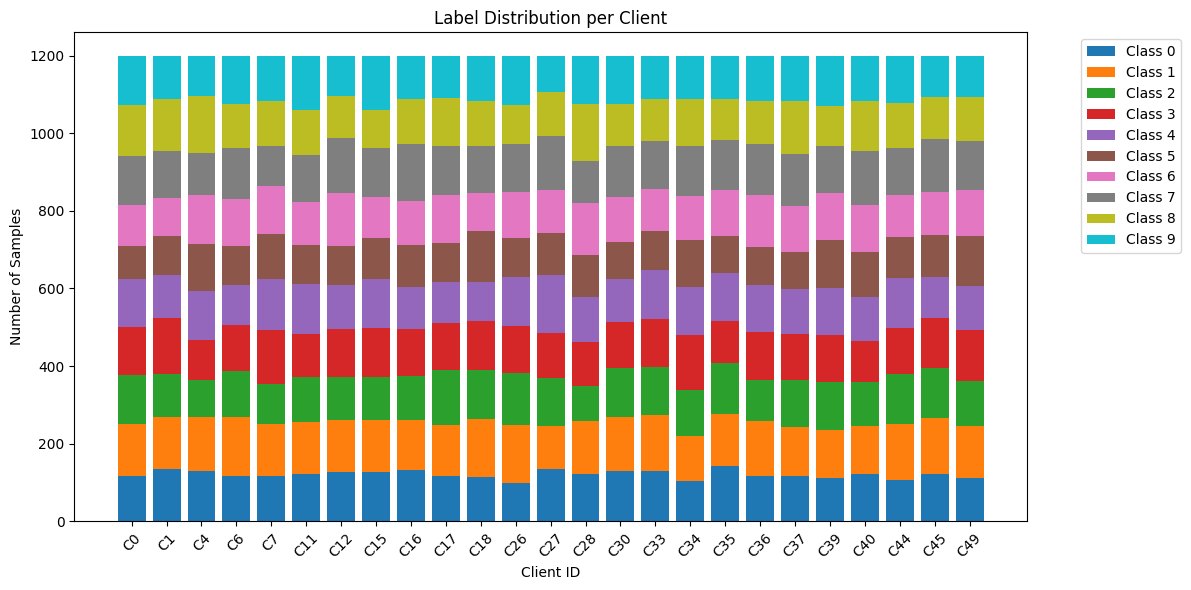

/tmp/ipykernel_1024/132743416.py:16: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  target_indices = np.where(np.array(trainset.targets) == args.target_class)[0]


[1/3] Optimizing Trigger...


/tmp/ipykernel_1024/2933962566.py:25: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  target_indices = np.where(np.array(dataset.targets) == target_class)[0]


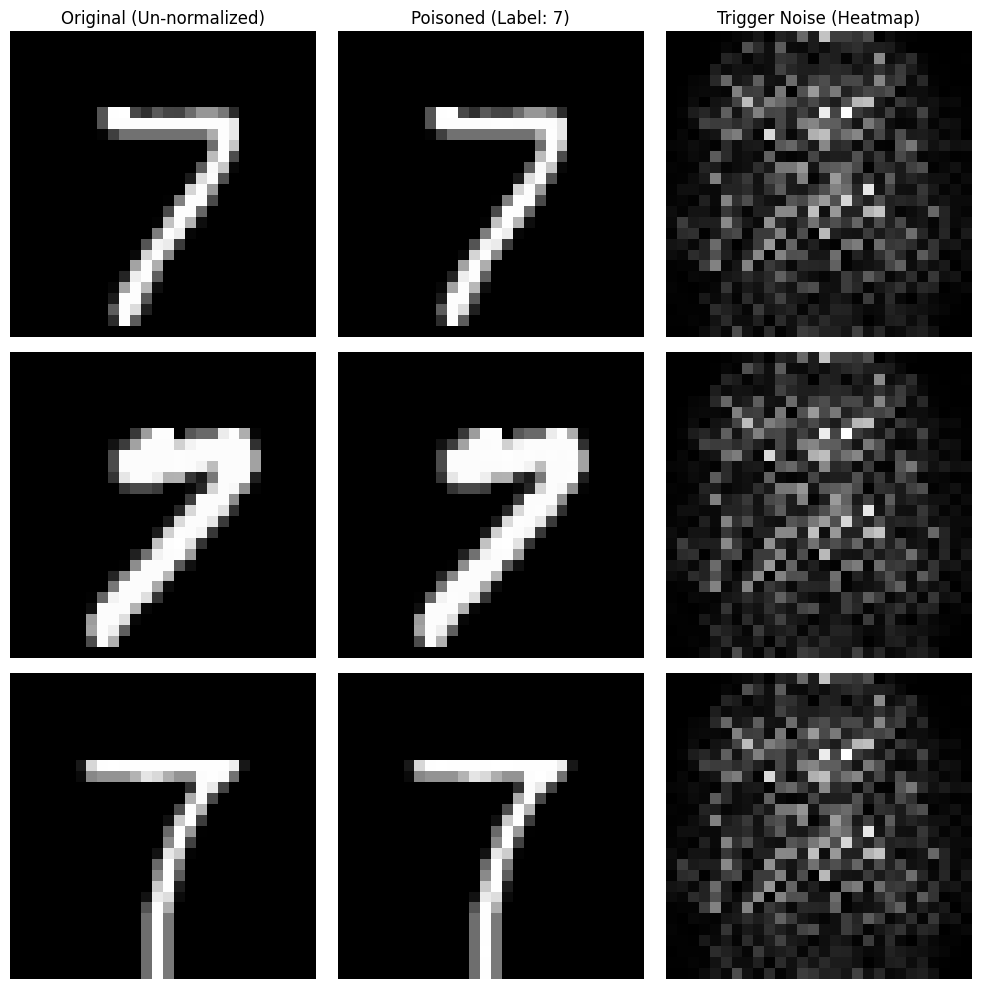

--- Trigger Power Check ---
Trigger Surrogate Success Rate: 100.00%
[2/3] Starting Training Loop...


/tmp/ipykernel_1024/3058154503.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  all_targets = np.array(dataset.targets)


Round 1 | Malicious Selected: 3 | ACC: 95.65% | ASR: 3.72%
Round 2 | Malicious Selected: 1 | ACC: 97.91% | ASR: 8.67%
Round 3 | Malicious Selected: 2 | ACC: 98.44% | ASR: 9.56%
Round 4 | Malicious Selected: 0 | ACC: 98.63% | ASR: 8.39%
Round 5 | Malicious Selected: 3 | ACC: 98.76% | ASR: 12.41%
Round 6 | Malicious Selected: 1 | ACC: 98.78% | ASR: 11.20%
Round 7 | Malicious Selected: 1 | ACC: 98.93% | ASR: 9.73%
Round 8 | Malicious Selected: 1 | ACC: 98.96% | ASR: 8.75%
Round 9 | Malicious Selected: 4 | ACC: 99.00% | ASR: 9.46%
Round 10 | Malicious Selected: 4 | ACC: 99.05% | ASR: 14.66%
Round 11 | Malicious Selected: 2 | ACC: 98.99% | ASR: 16.70%
Round 12 | Malicious Selected: 3 | ACC: 99.01% | ASR: 19.16%
Round 13 | Malicious Selected: 2 | ACC: 99.05% | ASR: 20.41%
Round 14 | Malicious Selected: 2 | ACC: 99.06% | ASR: 20.27%
Round 15 | Malicious Selected: 2 | ACC: 99.11% | ASR: 22.05%
Round 16 | Malicious Selected: 3 | ACC: 99.13% | ASR: 23.45%
Round 17 | Malicious Selected: 4 | ACC: 

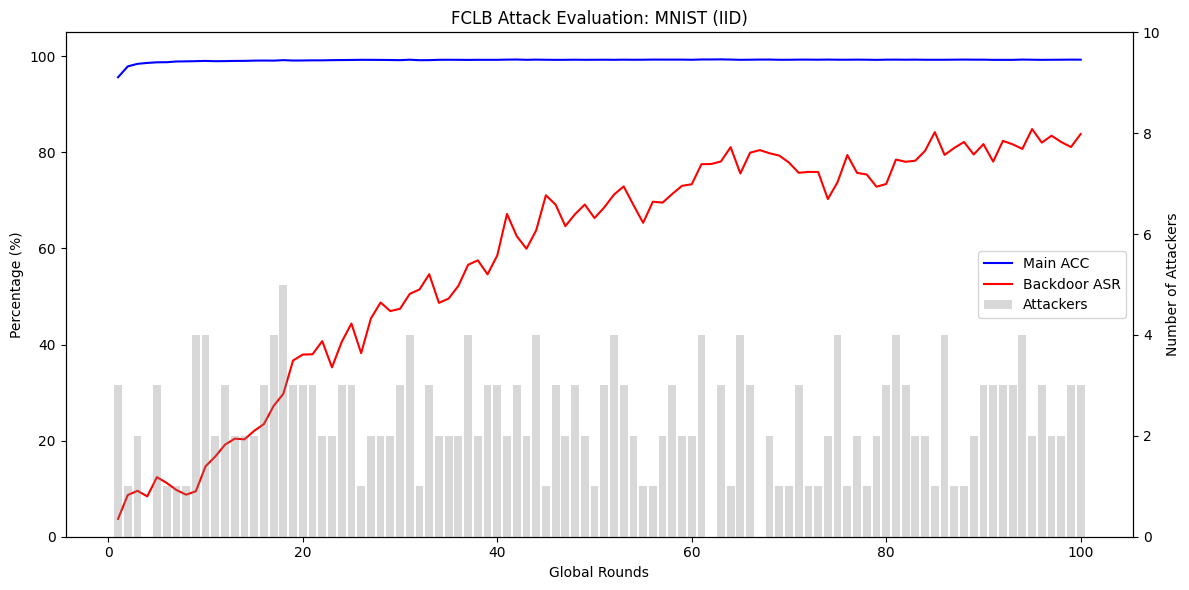

In [ ]:
def main():
    args = Args()
    device = get_device()
    
    print(f"--- FCLB Execution: Target {args.target_class} ---")

    trainset, testset = load_data_mnist()
    
    pood_raw = get_pood_dataset_fashion_mnist(size=1000)
    pood_dataset = ShiftedDataset(pood_raw, shift=10)
    
    target_indices = np.where(np.array(trainset.targets) == args.target_class)[0]
    attacker_knowledge = Subset(trainset, target_indices[:200]) 

    print("[1/3] Optimizing Trigger...")
    surrogate = get_resnet18_mnist(num_classes=20).to(device)
    
    generator = TriggerGenerator(surrogate, pood_dataset, attacker_knowledge, device, 
                                 target_class_idx=args.target_class, 
                                 epsilon=args.trigger_epsilon)
    
    trigger = generator.generate(t1=args.t1, t2=args.t2, t3=args.t3)
    visualize_trigger_effect(trainset, trigger, args.target_class, args.trigger_epsilon)
    
    log_trigger_power(surrogate, trigger, DataLoader(pood_dataset, batch_size=64), 
                      args.target_class, device)
    
    partition_methods = {
        "IID": get_iid_partitions,
        "Non-IID": get_non_iid_partitions
    }

    for partition_name, partition_func in partition_methods.items():
        print(f"\n{'='*50}")
        print(f"--- Partition name : {partition_name} ---")
        print(f"{'='*50}")
        
        set_seed(2026) 
        
        user_groups = partition_func(trainset, args.num_users)
        analyze_client_distribution(trainset, user_groups, subset_clients=25)
        
        global_model = SimpleCNN()
        server = Server(device, global_model, testset)
        
        clients = []
        malicious_ids = list(range(args.num_attackers)) 

        for i in range(args.num_users):
            if i in malicious_ids:
                clients.append(MaliciousClient(i, trainset, user_groups[i], device, 
                                              get_simple_cnn, args, trigger, 
                                              attacker_knowledge))
            else:
                clients.append(BenignClient(i, trainset, user_groups[i], device, 
                                            get_simple_cnn))

        print(f"[2/3] Starting Training Loop for {partition_name}...")
        for rnd in range(1, args.rounds + 1):
            idxs_users = np.random.choice(range(args.num_users), args.clients_per_round, replace=False)
            malicious_selected = sum([1 for idx in idxs_users if idx in malicious_ids])
            
            local_weights = []
            for idx in idxs_users:
                client = clients[idx]
                w = client.update_weights(server.global_model, args.local_ep, args.lr, rnd)
                local_weights.append(w)
                
            server.aggregate(local_weights) 
            
            acc, asr = server.evaluate(trigger, args.target_class)
            server.log_and_plot(rnd, args.clients_per_round, malicious_selected, acc, asr)

        print(f"[3/3] Training Complete for {partition_name}.")
        
        server.save_final_plots(partition_name=partition_name) 

if __name__ == '__main__':
    main()